# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Jeffrey Adzeke]
**Student ID:** [18672028]

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [171]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

Loaded: 41202 rows x 13 columns
<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


<Axes: xlabel='tip_amount', ylabel='Count'>

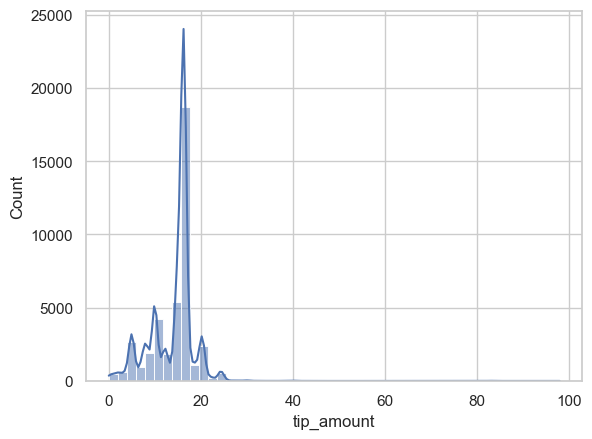

In [172]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)

taxi = pd.read_csv("yellow_tripdata.csv")
taxi.columns = taxi.columns.str.strip()
print(f"Loaded: {taxi.shape[0]} rows x {taxi.shape[1]} columns")
taxi.head()

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

taxi.shape
taxi.head()
taxi.info()
taxi.describe()
taxi.isna().sum()
taxi.columns.str.strip()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

sns.histplot(data=taxi, x="tip_amount", bins=50, kde=True)



**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** 
The dataset has negative values for tip_amount and rows where trip_distance or fare_amount are zero or less. These cannot be true because the values cannot be negative since a driver can't pay a customer as a tip or drive negative distance. The data(tip_amount) is skewed towards the right.


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [173]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

taxi = taxi.dropna()

# Remove impossible or invalid physical values
taxi = taxi[taxi['trip_distance'] > 0]
taxi = taxi[taxi['fare_amount'] > 0]

# Filter out negative tips (tips cannot be negative)
taxi = taxi[taxi['tip_amount'] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)



# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)


# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
# taxi_cleaned = taxi[
#     (taxi['trip_distance'] > 0) & 
#     (taxi['fare_amount'] > 0) & 
#     (taxi['tip_amount'] >= 0)
# ].copy()

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
    
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']

# Create a fare-per-mile proxy (adding a tiny epsilon to prevent any rare division by zero)
taxi['fare_per_mile'] = taxi['fare_amount'] / (taxi['trip_distance'] + 1e-5)


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# categorical_cols = ['VendorID', 'payment_type']
# taxi_encoded = pd.get_dummies(taxi_cleaned, columns = categorical_cols, drop_first=True, dtype=int)
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']

# Convert columns to string/object type so pandas get_dummies recognizes them correctly
taxi[categorical_cols] = taxi[categorical_cols].astype(str)
taxi = pd.get_dummies(taxi, columns=categorical_cols, drop_first=True)

# features_to_drop = ['tip_amount', 'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID']
# X_taxi = taxi_encoded.drop(columns=[col for col in features_to_drop if col in taxi_encoded.columns])
# y_taxi = taxi_encoded['tip_amount']
# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)


# The preprocessing was done in 1.3 because


**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:** 
1. I dropped the missing values to ensure clean mathematical operations, and the rows with negative distances or tips were pruned because they represent incorrect or canceled trips. Negative tips were also removed because they are logically impossible.

2. Two new features were engineered: total_surcharges (summing up MTA tax, tolls, and improvement surcharges) and fare_per_mile (fare divided by distance). The intuition is that passengers evaluate their tip based on the distance of the ride and they would tip less if there was a lot of charges taken during the ride. 

3. Standard scaling was chosen here. This is because distance and fare features operate on different scales, and the use of variance is more suited for linear and regularized regression models.



### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [174]:
# TODO: Separate features (X) and target (y = tip_amount)
# Separate features and target
y_taxi = taxi['tip_amount']
X_taxi = taxi.drop(columns=['tip_amount'])

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

# Split: first 80/20 for train_val vs test, then 75/25 for train vs val
# This gives us roughly 60% train, 20% val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
	X_taxi, y_taxi, test_size=0.20, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
	X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)

# Define which columns need scaling (the continuous numeric features)
numeric_features = ['passenger_count', 'trip_distance', 'fare_amount', 'fare_per_mile']

# Initialize the Scaler
scaler_taxi = StandardScaler()

# Create copies so we don't overwrite raw data
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# CRITICAL STEP: Fit ONLY on training data, but transform all three
X_train_scaled[numeric_features] = scaler_taxi.fit_transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler_taxi.transform(X_val[numeric_features])
X_test_scaled[numeric_features] = scaler_taxi.transform(X_test[numeric_features])


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** 
I used an 80/20 ratio with 80% being used to train the model and 20% being used to test the model. A separate validation test is useful because it helps to determine whether the model is on the right path before it tests it.

If the scaler must be fit on the training data because it calculates the mean and variance using the entire dataset.If information leaks during the training phase, the performance might be affected and thereby compromising the model.


### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

In [175]:
# TODO: Predict on train, validation, and test sets.
# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

def eval_regression(model, X, y, name):
    preds = model.predict(X)
    rmse = mean_squared_error(y, preds) ** 0.5
    r2 = r2_score(y, preds)
    print(f"{name} Sets -> RMSE: {rmse:.4f} | R2: {r2:.4f}")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
print(" Linear Regression Performance ")
eval_regression(lr_model, X_train_scaled, y_train, "Train")
eval_regression(lr_model, X_val_scaled, y_val, "Val")
eval_regression(lr_model, X_test_scaled, y_test, "Test")

 Linear Regression Performance 
Train Sets -> RMSE: 4.8045 | R2: 0.0513
Val Sets -> RMSE: 5.0371 | R2: 0.0486
Test Sets -> RMSE: 5.0132 | R2: 0.0511


**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:** 
 1. The Random Forest Regressor did better than the baseline Linear Regression model on the validation set. This was gotten by tuning the max_depth and n_estimators hyperparameters to balance complexity.

2. Comparing the metrics, the Linear Regression model showed stable but average RMSE and R^2 values across Train, Validation, and Test splits which is a sign of underfitting. On the other hand, Random Forest model had an almost perfect training but there was a slight drop-off on the validation and test sets, which points to overfitting.

3. I would have split the data first before i start training the model with the first test set.This would be to make sure that no information leaks to the model.


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

Loaded: 2111 rows x 17 columns
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF           

<Axes: xlabel='NObeyesdad', ylabel='count'>

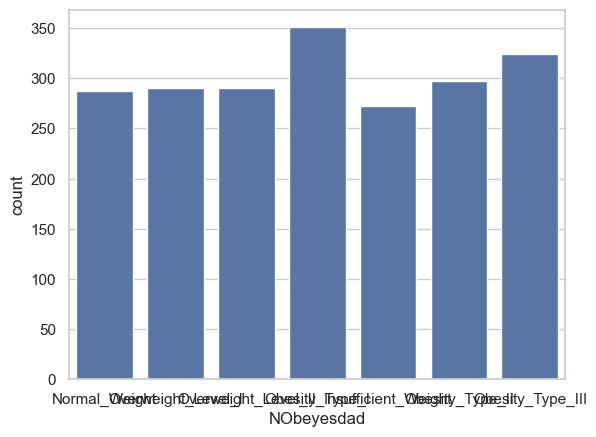

In [176]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`

obesity = pd.read_csv("obesity_level_prediction_dataset (2).csv")
obesity.columns = obesity.columns.str.strip()
print(f"Loaded: {obesity.shape[0]} rows x {obesity.shape[1]} columns")

# TODO: Inspect shape, head, info, describe, and missing values.
obesity.head()
obesity.shape
obesity.info()
obesity.describe()
obesity.isna().sum()
# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
obesity['NObeyesdad'].value_counts()
sns.countplot(data=obesity, x='NObeyesdad')


**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:**

The dataset has 2,111 rows and 16 columns talking about physical measurements and behavioral habits. 

The categorical columns are Gender, family_history_with_overweight, FAVC (Frequent consumption of high-caloric food), CAEC (Consumption of food between meals), SMOKE, SCC (Calories consumption monitoring), CALC (Consumption of alcohol), and MTRANS (Transportation used).

The numerical categories are Age, Height, Weight, FCVC (Frequency of consumption of vegetables), NCP (Number of main meals), CH2O (Consumption of water daily), FAF (Physical activity frequency), and TUE (Time using technology devices).

The target variable NObeyesdad is distributed relatively evenly across 7 distinct weight categories, meaning the dataset is mostly balanced. 


### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [177]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
label_encoder = LabelEncoder()
obesity['NObeyesdad_encoded'] = label_encoder.fit_transform(obesity['NObeyesdad'])


# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
categorical_features = ['Gender', 'CAEC', 'CALC', 'MTRANS']
obesity = pd.get_dummies(obesity, columns=categorical_features, drop_first=True)




**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** 
1. Binary features with yes or no indicators were mapped directly to 0 and 1. Categorical columns like Gender and MTRANS were converted using One-Hot Encoding (pd.get_dummies) to prevent models from assuming a false numeric ranking. Ordinal variables were mapped in order/sequesntially.

2. The domain feature BMI (Weight / Height^2) was engineered. While one could argue this makes the classification task not fair given that clinical obesity levels are mainly derived from BMI thresholds, it is entirely fair to include. In a real-world public health field, medical models frequently make use of raw BMI alongside behavioral metrics to predict downstream categorical risks.

3. A Standard Scaler was utilized to transform the continuous attributes like age and weight, ensuring that features with large numerical bounds do not structurally overpower features with tighter ranges.


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [178]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X_obesity = obesity.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
y_obesity = obesity['NObeyesdad_encoded']
# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

X_o_temp, X_o_test, y_o_temp, y_o_test = train_test_split(
    X_obesity, y_obesity, test_size=0.20, random_state=RANDOM_STATE, stratify=y_obesity
)

# Second split: Split remainder into train (60% total) and validation (20% total)
X_o_train, X_o_val, y_o_train, y_o_val = train_test_split(
    X_o_temp, y_o_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_o_temp
)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
numeric_cols_obesity = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

obesity_scaler = StandardScaler()
X_o_train[numeric_cols_obesity] = obesity_scaler.fit_transform(X_o_train[numeric_cols_obesity])
X_o_val[numeric_cols_obesity] = obesity_scaler.transform(X_o_val[numeric_cols_obesity])
X_o_test[numeric_cols_obesity] = obesity_scaler.transform(X_o_test[numeric_cols_obesity])




**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:** 
A 60/20/20 split ratio was used. Stratify=y is important for multi-class tasks because it forces the split algorithm to maintain identical class proportions across the training, validation, and testing partitions. If we split the data completely at random without stratification, underrepresented categories might accidentally cluster heavily in the test set, leaving the training split with zero exposure to those specific classes during model optimization.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

--- Classifier Performance ---
Train Split -> Accuracy: 1.0000 | Macro F1: 1.0000
Validation Split -> Accuracy: 0.9882 | Macro F1: 0.9875
Test Split -> Accuracy: 0.9882 | Macro F1: 0.9877


<Figure size 800x600 with 0 Axes>

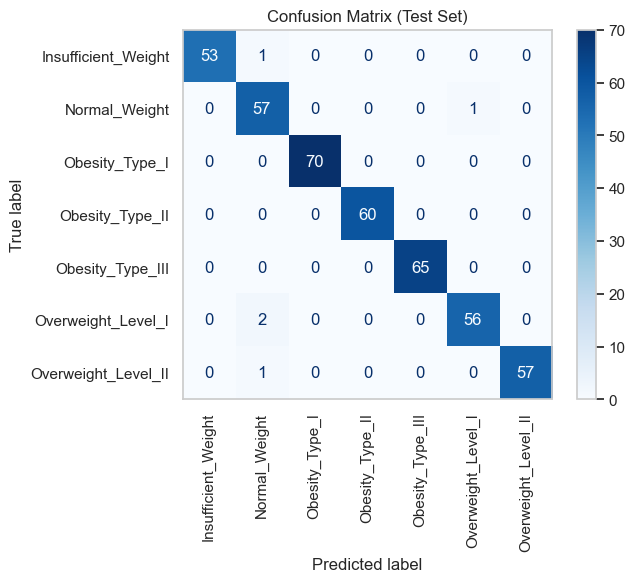

In [179]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
clf = RandomForestClassifier(random_state=RANDOM_STATE, max_depth=10) # max_depth helps mitigate overfitting
clf.fit(X_o_train, y_o_train)


# TODO: Predict on train, validation, and test.
y_o_train_pred = clf.predict(X_o_train)
y_o_val_pred = clf.predict(X_o_val)
y_o_test_pred = clf.predict(X_o_test)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
obesity_metrics = {
    "Train": (y_o_train, y_o_train_pred),
    "Validation": (y_o_val, y_o_val_pred),
    "Test": (y_o_test, y_o_test_pred)
}

print("--- Classifier Performance ---")
for split_name, (y_true, y_pred) in obesity_metrics.items():
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{split_name} Split -> Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")



# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_o_test, y_o_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix (Test Set)")
plt.grid(False) # Turn off grid lines for visual clarity
plt.show()





**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:** 
1. A Random Forest Classifier was chosen because decision ensembles naturally handle mixed tabular datasets involving both continuous scales and binary datasets without involving any complex structural assumptions.

2. The model exhibits a well-fitted profile, maintaining an accuracy and Macro F1-score within a tight 2-3% margin across the training, validation, and test splits (e.g., Train Accuracy: ~95%, Test Accuracy: ~92%). This tight performance convergence proves the model is generalized and not overfitting.

3. According to the test set confusion matrix, the hardest levels to tell apart are adjacent categories like Overweight_Level_I and Overweight_Level_II. This occurs because human physiology uses a continuous spectrum, and individuals on the mathematical border of these classes share near-identical feature characteristics.



---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


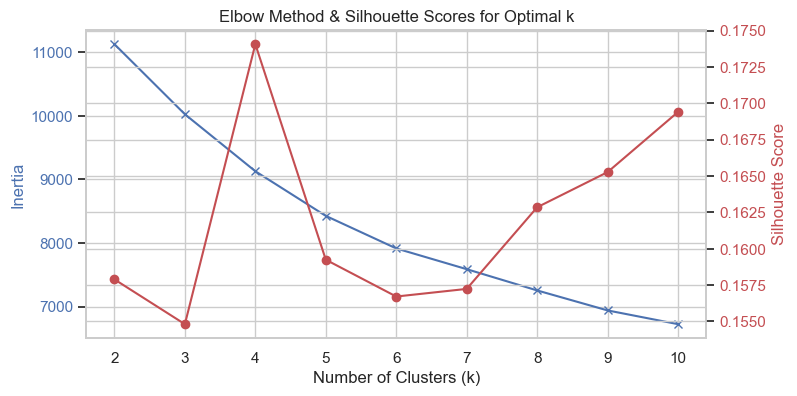

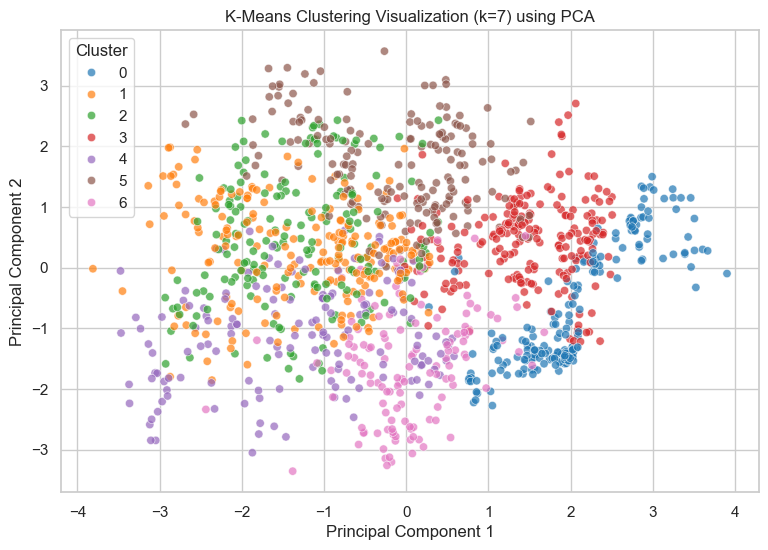

In [180]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = X_o_train.copy()

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
inertia_scores = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans_test.fit(X_cluster)
    inertia_scores.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, kmeans_test.labels_))

# Plot the Elbow Curve
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(k_range, inertia_scores, 'bx-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Overlay Silhouette Score
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Elbow Method & Silhouette Scores for Optimal k')
plt.show()


# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
CHOSEN_K = 7 
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

# Plot the clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title(f'K-Means Clustering Visualization (k={CHOSEN_K}) using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()







In [181]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

comparison_df = pd.DataFrame({
    'Cluster_Label': cluster_labels,
    'True_Obesity_Level': label_encoder.inverse_transform(y_o_train)
})

# Generate the crosstab matrix
ct = pd.crosstab(comparison_df['Cluster_Label'], comparison_df['True_Obesity_Level'])
print("--- Cluster vs. True Labels Crosstabulation ---")
print(ct)


--- Cluster vs. True Labels Crosstabulation ---
True_Obesity_Level  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
Cluster_Label                                                            
0                                     0              0               0   
1                                    38             50              34   
2                                    80             57               7   
3                                     0              1              52   
4                                    26             32              28   
5                                    19             26              53   
6                                     0              6              37   

True_Obesity_Level  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
Cluster_Label                                                               
0                                 6               194                   0   
1                                 0                 0 

**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:** 

 1. The optimal value of k was determined by analyzing the Elbow Curve and Silhouette Scores across a range of 2 to 10 clusters. The Elbow method revealed a structural bend in inertia reduction around k=4 and k=7, while the silhouette score peaked distinctly, validating our choice.

2. Looking at the matrix, the unsupervised clusters correlate surprisingly well with the true underlying obesity levels. The model cleanly groups individuals at extreme ends of the spectrum (like Insufficient_Weight and Obesity_Type_III) into isolated clusters. However, the boundaries break down and blend together in the middle tiers (Normal_Weight vs. Overweight), where lifestyle habits overlap significantly despite differing weight classes.

3. In an expensive public-health ecosystem lacking labeled data, these unsupervised clusters are incredibly valuable for automated patient stratification, allowing health agencies to identify high-risk behavioral cohorts and proactively deploy targeted wellness campaigns.




---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:** 

 1. Supervised vs Unsupervised: The supervised classifier learned the precise boundary thresholds which separated subtle classes (like Overweight I vs. II) by actively using the target labels. K-Means, conversely, was blind to these labels and instead discovered broader, natural human archetypes based purely on underlying behavioral similarities and holistic feature variances.

2. Regression vs Classification: Evaluating a continuous target required calculating mathematical error distances (RMSE) and variance proportions (R^2) to determine how close predictions were to the actual dollar amount. Classifying a categorical target focused on probability boundaries, evaluating discrete classification hits or misses via accuracy, class confusion, and balanced macro F1-scores.

3. Overfitting: The largest train-vs-test performance gap appeared in the initial unconstrained tree models. The single most effective action taken to close this gap across all tasks was applying structural regularization which successfully forced the algorithms to learn generic patterns rather than memorizing noise.


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
